In [ ]:
#Milestone-3: Geographic Analysis of US Natural Disasters
#Objective: Analyze and visualize the geographical distribution of natural disaster declarations across the United States.

#Key Questions:

#Which states have the highest number of disaster declarations?
#Are disasters concentrated in certain regions?
#Do specific incident types occur more frequently in specific states?
#Can geographical hotspots be identified?

In [ ]:
#Import & Load Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("usnd_cleaned.csv")

sns.set_style("darkgrid")

In [17]:
#State-wise Aggregation
state_counts = df['state'].value_counts().rename_axis('state').reset_index(name='disaster_count')

In [18]:
state_counts.head()

,state,disaster_count
0,TX,3842
1,MO,2263
2,KY,2026
3,VA,1982
4,OK,1882


In [4]:
#Data Check (info, null, unique)
df.info()
df.isnull().sum()
df['state'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46185 entries, 0 to 46184
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   state         46185 non-null  object
 1   incidentType  46185 non-null  object
 2   date          46185 non-null  object
 3   year          46185 non-null  int64 
 4   month         46185 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.8+ MB


array(['GA', 'TX', 'LA', 'MI', 'MT', 'MA', 'IA', 'NH', 'FL', 'AK', 'MS',
       'CA', 'NV', 'SD', 'WV', 'RI', 'ME', 'CT', 'NY', 'NM', 'NC', 'SC',
       'IN', 'HI', 'CO', 'KS', 'OK', 'PA', 'NJ', 'OR', 'WA', 'ID', 'OH',
       'PR', 'KY', 'VA', 'MO', 'AR', 'IL', 'ND', 'MN', 'NE', 'AL', 'DE',
       'MD', 'GU', 'TN', 'FM', 'WY', 'VT', 'VI', 'WI', 'AS', 'AZ', 'PW',
       'MP', 'UT', 'MH', 'DC'], dtype=object)

In [19]:
grouped_data = df.groupby(['state','incidentType']).size().reset_index(name='count')
grouped_data.head()

,state,incidentType,count
0,AK,Earthquake,7
1,AK,Fire,16
2,AK,Flood,46
3,AK,Other,4
4,AK,Snow,4


In [ ]:
#Top States Selection
top_states = state_counts.iloc[:10]

C:\Users\jusup\AppData\Local\Temp\ipykernel_22868\2078900353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


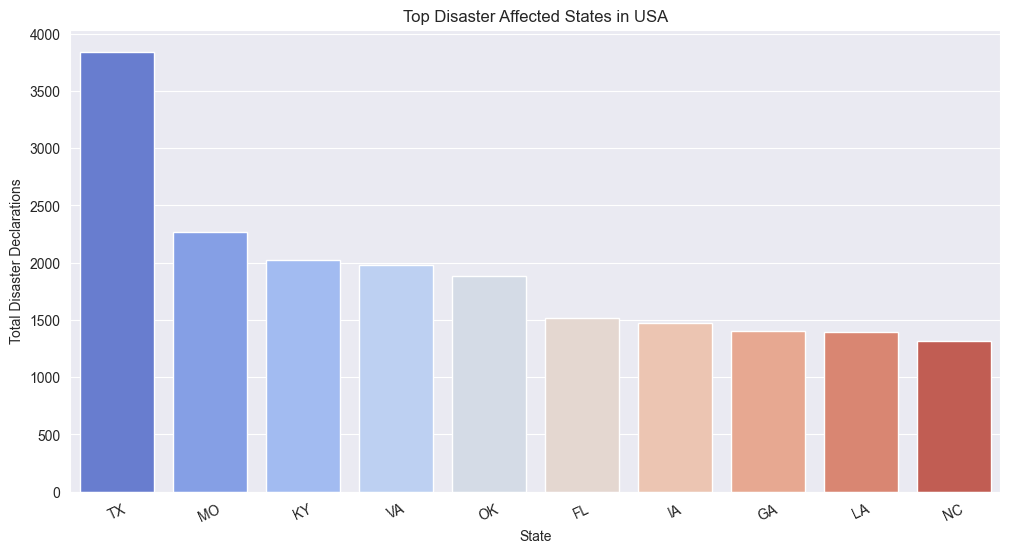

In [6]:
#Bar Chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_states,
    x='state',
    y='disaster_count',
    palette='coolwarm'
)

plt.title("Top Disaster Affected States in USA")
plt.xlabel("State")
plt.ylabel("Total Disaster Declarations")
plt.xticks(rotation=25)

plt.show()

In [ ]:
#Incident Type Distribution (crosstab)
incident_table = pd.crosstab(df['state'], df['incidentType'])

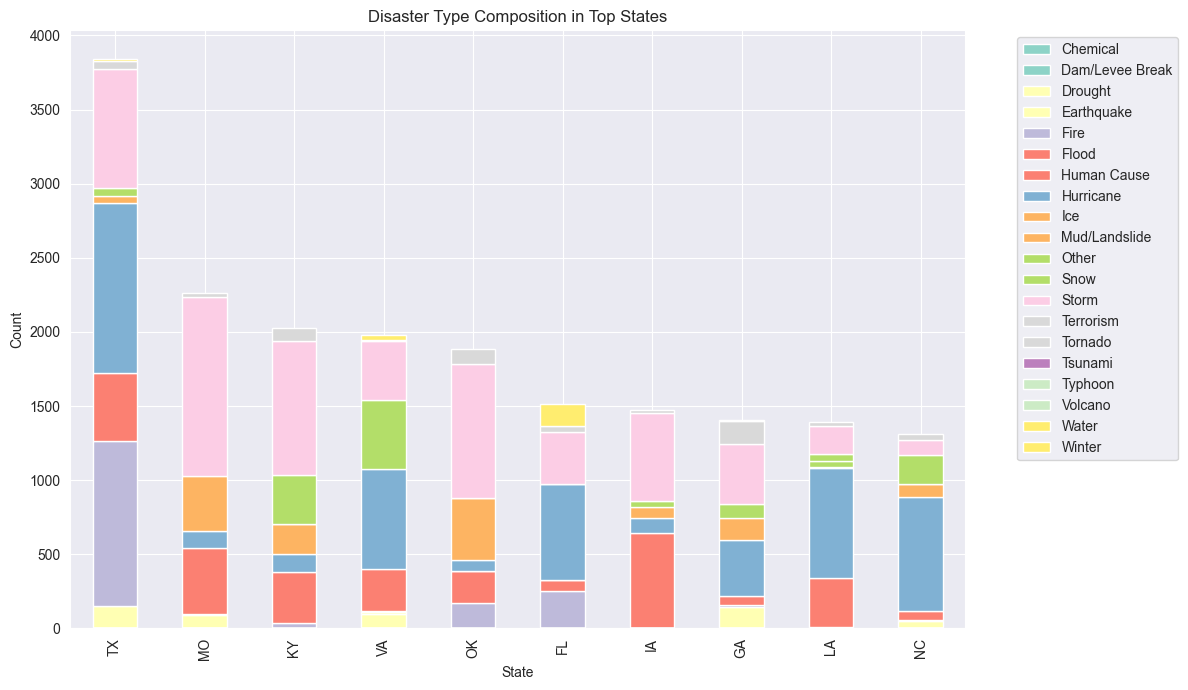

In [8]:
#Stacked Bar Chart
incident_top = incident_table.loc[top_states['state']]

incident_top.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    colormap='Set3'
)

plt.title("Disaster Type Composition in Top States")
plt.xlabel("State")
plt.ylabel("Count")

plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

In [16]:
#Choropleth Map
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook_connected"

fig = px.choropleth(
    state_counts,
    locations='state',
    locationmode='USA-states',
    color='disaster_count',
    scope='usa',
    color_continuous_scale='Viridis',
    title="Geographical Spread of Disaster Declarations"
)

fig.show()

In [15]:
#Hotspot Map (Hurricane)
hurricane_data = df[df['incidentType'] == "Hurricane"]

hurricane_counts = hurricane_data['state'].value_counts().reset_index()
hurricane_counts.columns = ['state','count']

import plotly.express as px

fig = px.choropleth(
    hurricane_counts,
    locations='state',
    locationmode="USA-states",
    color='count',
    scope="usa",
    title="Hurricane Disaster Hotspots"
)

fig.show()

In [ ]:
#Region Analysis
region_map = {
    'CA':'West','TX':'South','FL':'South','NY':'Northeast',
    'IL':'Midwest','WA':'West','OR':'West','GA':'South'
}

df['region'] = df['state'].map(region_map)

region_counts = df['region'].value_counts().reset_index()
region_counts.columns = ['region','count']

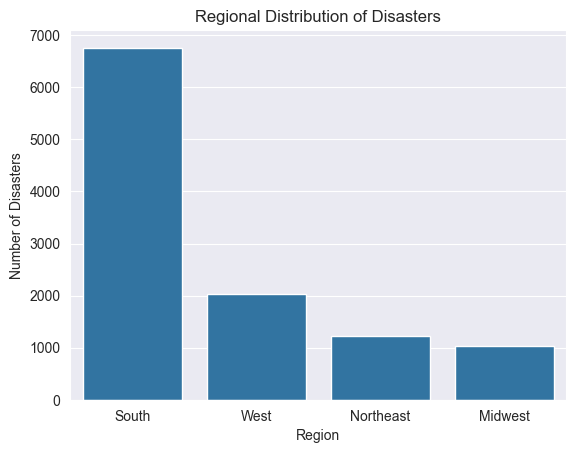

In [13]:
sns.barplot(data=region_counts, x='region', y='count')

plt.title("Regional Distribution of Disasters")
plt.xlabel("Region")
plt.ylabel("Number of Disasters")

plt.show()